# Enroll a new device from a `.nam` capture (no recording needed)

Same goal as [`enroll_new_device.ipynb`](enroll_new_device.ipynb) — fit an **embedding** for one device against a frozen one-to-many run — but the device's response is **synthesized**, not recorded, so there's nothing to capture and nothing to align. **You provide one thing: `NAM_PATH`.** The notebook picks up the TONE3000 sweep from `data/raw/nam_sweep/`, renders it through the capture to build the wet/dry pair itself, and fits the embedding on it (Phase 5, `openamp.emulate.enroll.enroll_pair`).

Why this is simpler than the recorded-pair flow:

- **No reamp latency, no alignment.** The wet sweep is a deterministic render of the dry sweep, so the pair is sample-aligned *by construction* — the #1 error source in the recorded flow (a constant wet/dry offset the embedding can't absorb) simply doesn't exist here.
- **No capture session.** Any of the ~2,000 `.nam` files under `data/captures/` can be enrolled straight from disk: a device the frozen run never saw becomes a conditioning vector in a couple of minutes.

The `.nam` is the ground truth — the wet sweep it produces is exactly what the embedding learns to reproduce, and the A/B at the end pits the enrolled one-to-many model against that same `.nam` render.

1. Set `NAM_PATH` to the capture to enroll (and pick the run via `RUN_DIR`).
2. Run all cells: the sweep is auto-located, rendered through the `.nam` at its native level, split into **NAM's own train/val regions** (the trainer's layout from `nam/train/core.py` — lead-in dropped, blips kept, ESR scored on the dedicated 9 s tail rather than a blind last-`VAL_FRAC` slice; see the sections cell), and enrolled on a pure pre-emphasized-ESR objective (`STFT_WEIGHT = 0` — measured to be essential here, see the notes).
3. Listen: dry → wet (`.nam` target) → enrolled-model prediction on the val region.
4. Export: writes a pasteable `profile.json` (`{name, run, dim, embedding}`) for the morph plugin.

- Kernel: the **open-amp3000** conda env (Python 3.10).
- Runs on **CPU** by default so it never competes with a live training run.
- Artifacts land in `<run>/enroll/pairs/<NAME>/` — same layout as the recorded flow, so `load_pair_model(RUN_DIR, NAME)` rebuilds the playable model and `profile.json` is the plugin-ready embedding.

In [ ]:
import os
from pathlib import Path

if not Path('configs').is_dir() and (Path.cwd().parent / 'configs').is_dir():
    os.chdir(Path.cwd().parent)   # run from repo root
print('cwd:', Path.cwd())

import numpy as np

from openamp.core.config import load_config

# ---- input (the only thing you set) ---------------------------------------
NAM_PATH = Path('data/captures/manual/7. EVH Stealth G6 B7 M5 T7 P7 D5.nam')   # the .nam capture to enroll

# ---- defaults you rarely touch --------------------------------------------
RUN_DIR    = Path('results/emulate/nam_a2_tanh_ch16_512')     # frozen run to enroll against
NAME       = None    # artifact name (enroll/pairs/<NAME>/); None -> from NAM_PATH
DRY_SOURCE = 'sweep' # 'sweep' (T3K capture signal) | 'corpus' (clean train DI --
                     #   the frozen net's own input distribution; ~2x lower val ESR)
SWEEP_PATH = None    # override the sweep file; None -> auto-find in data/raw/nam_sweep/

# ---- knobs ------------------------------------------------------------------
DEVICE      = 'cuda'  # used for BOTH the .nam render and the fit
PAIRS       = 500    # optimization windows per epoch (steps/epoch = PAIRS / BATCH)
BATCH       = 8      # fit batch size; fp32 (no autocast), so a run's own batch (32)
                     #   OOMs a 12 GB card alongside the .nam -- 8 fits fine
EPOCHS      = 400     # max epochs
LR          = 5.0e-3
VAL_FRAC    = 0.1    # last 10% of the pair is held back for val
EARLY_STOP  = 40      # stop after N epochs with no val-ESR gain; <= 0 -> run all EPOCHS
INIT        = 'uniform'  # new row's start: 'uniform' = U(-a,a) at the trainer's own
                     #   init variance (a device starts where every trained device
                     #   started) | 'table_mean' = every row at the trained table's
                     #   mean (lower baseline, but not a point any device occupies)
STFT_WEIGHT = 0.0    # loss = preemph-ESR + this * multi-res STFT. Keep 0.0: with the
                     #   run's trained weight the STFT term dominates a pair fit and
                     #   val ESR rises from the baseline instead of falling
LR_PATIENCE = 5      # ReduceLROnPlateau: epochs with no val gain before LR *= LR_FACTOR
LR_FACTOR   = 0.5

cfg = load_config()
if NAME is None:
    NAME = f'nam_{NAM_PATH.stem}'
print(f'run={RUN_DIR.name}  sample_rate={cfg.sample_rate}  enroll_name={NAME}')

In [2]:
from openamp.dsp.nam import parse_nam

# Select the .nam model. Any capture under data/captures/ can be enrolled; set
# NAM_PATH above to one of these and re-run from here.
captures = sorted(cfg.captures_dir.rglob('*.nam'))
print(f'{len(captures)} .nam captures under {cfg.captures_dir}; e.g.:')
for p in captures[:8]:
    print('   ', p.relative_to(cfg.captures_dir))

if not NAM_PATH.is_file():
    raise FileNotFoundError(f'NAM_PATH not found: {NAM_PATH}')
info = parse_nam(NAM_PATH)
print(f'\nselected: {NAM_PATH}')
print(f"  arch={info['architecture']}  sample_rate={info['sample_rate']}  "
      f"has_weights={info['has_weights']}")
meta = info.get('metadata') or {}
shown = {k: meta[k] for k in ('name', 'modeled_by', 'gear_make', 'gear_model',
                              'tone_type') if k in meta}
if shown:
    print('  metadata:', shown)

2079 .nam captures under data/captures; e.g.:
    1053/420096.nam
    1053/82190.nam
    1066/420088.nam
    1066/82108.nam
    1066/82109.nam
    1066/82110.nam
    1066/82111.nam
    1066/82112.nam

selected: data/captures/manual/7. EVH Stealth G6 B7 M5 T7 P7 D5.nam
  arch=SlimmableContainer  sample_rate=48000  has_weights=True
  metadata: {'name': '7. EVH Stealth G6 B7 M5 T7 P7 D5', 'modeled_by': 'mattvdh', 'gear_make': 'T3K-Null', 'gear_model': 'T3K-Null', 'tone_type': 'metal'}


In [ ]:
from openamp.core import manifest as manifests
from openamp.dsp.audio import peak_dbfs, read_audio, resample, rms_dbfs


def find_sweep():
    # SWEEP_PATH if set, else the canonical v3_0_0.wav, else any .wav in
    # data/raw/nam_sweep/, so a fresh checkout just works.
    if SWEEP_PATH is not None:
        return Path(SWEEP_PATH)
    if cfg.nam_sweep_path.is_file():
        return cfg.nam_sweep_path
    hits = sorted(cfg.nam_sweep_path.parent.glob('*.wav'))
    if hits:
        return hits[0]
    raise FileNotFoundError(
        f'no sweep found in {cfg.nam_sweep_path.parent} -- drop the TONE3000 '
        'sweep .wav there, or set SWEEP_PATH')


if DRY_SOURCE == 'corpus':
    # The exact input distribution the frozen net trained on (per-file
    # leveled, peak-capped).
    corpus = manifests.read_manifest(cfg.corpus_manifest_path, manifests.CORPUS_COLUMNS)
    files = [cfg.clean_split_dir('train') / f'{fid}.{cfg.output_format}'
             for fid in corpus[corpus['split'] == 'train']['file_id']]
    parts = []
    for p in files:
        if p.is_file():
            x, sr = read_audio(p)
            parts.append(resample(x, sr, cfg.sample_rate))
    if not parts:
        raise FileNotFoundError('no clean train renders -- run `openamp corpus` '
                                "or use DRY_SOURCE='sweep'")
    dry = np.concatenate(parts).astype(np.float32)
    dry_src = f'clean corpus train split ({len(parts)} files)'
else:
    sweep_path = find_sweep()
    x, sr = read_audio(sweep_path)
    dry = resample(x, sr, cfg.sample_rate).astype(np.float32)
    dry_src = str(sweep_path)

# Native level, deliberately un-normalized: the sweep's own stats already sit
# inside the frozen net's training input range, and RMS-matching the whole
# file to -18 dBFS would overshoot (quiet sections drag the whole-file RMS down).
print(f'dry source: {dry_src}')
print(f'dry: {len(dry) / cfg.sample_rate:.1f}s   rms {rms_dbfs(dry):6.1f} dBFS  '
      f'peak {peak_dbfs(dry):6.1f} dBFS  (native level)')

In [ ]:
import matplotlib.pyplot as plt

from openamp.corpus.render import chunked_forward
from openamp.dsp import nam as nam_dsp

model = nam_dsp.load_model(NAM_PATH, device=DEVICE)
print(f'.nam loaded: sr={model.sample_rate}Hz  R={model.receptive_field}  '
      f'sha={model.nam_sha256[:12]}')


def render_through_nam(x):
    # Whole-file chunked render with real left-context (resample-aware) --
    # bit-identical to a single full-file forward.
    if model.sample_rate == cfg.sample_rate:
        return chunked_forward(model.forward, x, model.receptive_field, cfg.chunk_samples)
    xr = resample(x, cfg.sample_rate, model.sample_rate)
    chunk = int(round(cfg.chunk_seconds * model.sample_rate))
    yr = chunked_forward(model.forward, xr, model.receptive_field, chunk)
    return resample(yr, model.sample_rate, cfg.sample_rate)


wet = render_through_nam(dry).astype(np.float32)
n = min(len(dry), len(wet))
dry, wet = dry[:n].copy(), wet[:n].copy()          # equal length for enroll_pair
print(f'wet: rms {rms_dbfs(wet):6.1f} dBFS  peak {peak_dbfs(wet):6.1f} dBFS   '
      f'pair={n / cfg.sample_rate:.1f}s')

# Wet is a deterministic render of dry -> sample-aligned by construction (no
# reamp latency). Left: 2s overview. Right: onset overlay, peak-normalized --
# the edges sit on the black line with zero offset (nothing to correct).
o = n // 3
end = min(o + 2 * cfg.sample_rate, n)
k = int(np.argmax(np.abs(np.diff(dry)))); w = 60    # sharpest dry edge, +-60 smp
z0, z1 = max(k - w, 0), min(k + w, n)
fig, (axl, axr) = plt.subplots(1, 2, figsize=(12, 2.8),
                               gridspec_kw={'width_ratios': [2, 1]})
axl.plot(np.arange(end - o) / cfg.sample_rate, dry[o:end], lw=0.6, alpha=0.8, label='dry')
axl.plot(np.arange(end - o) / cfg.sample_rate, wet[o:end], lw=0.6, alpha=0.8, label='wet (.nam)')
axl.set_xlabel('s'); axl.set_title('dry vs .nam render (2 s excerpt)')
axl.legend(loc='upper right')
nd = dry[z0:z1] / (np.max(np.abs(dry[z0:z1])) + 1e-9)
nw = wet[z0:z1] / (np.max(np.abs(wet[z0:z1])) + 1e-9)
axr.plot(np.arange(z0, z1) - k, nd, marker='.', ms=3, lw=0.8, label='dry')
axr.plot(np.arange(z0, z1) - k, nw, marker='.', ms=3, lw=0.8, label='wet')
axr.axvline(0, color='k', lw=0.5, alpha=0.4)
axr.set_xlabel('samples from transient')
axr.set_title('onset overlay (aligned by construction)')
axr.legend(loc='upper right')
plt.tight_layout(); plt.show()

In [ ]:
from openamp.emulate.enroll import nam_signal_regions

# Follow NAM's OWN train/val split rather than a blind last-VAL_FRAC slice:
# the v3 sweep has a 10s lead-in NAM discards, calibration blips it keeps in
# train, then a dedicated 9s val block at the tail that NAM reports ESR on.
# Applies only to the standard sweep; DRY_SOURCE='corpus' has no such
# structure and falls back to the plain VAL_FRAC split.
regions = nam_signal_regions(n, sample_rate=cfg.sample_rate) if DRY_SOURCE == 'sweep' else None
sr = cfg.sample_rate

if regions is None:
    why = 'corpus DI' if DRY_SOURCE != 'sweep' else f'{n} not a recognized NAM signal'
    print(f'no NAM sections ({why}) -> plain val_frac={VAL_FRAC} time split')
else:
    tr, vr, li, bl = regions['train'], regions['val'], regions['lead_in'], regions['blips']
    print(f"NAM {regions['version']} layout ({n / sr:.1f}s):")
    print(f'  lead-in  {li[0]/sr:6.1f}-{li[1]/sr:6.1f}s   discarded (not trained on)')
    print(f'  blips    @ {bl[0]/sr:.1f}s, {bl[1]/sr:.1f}s      latency cal (kept in train)')
    print(f'  TRAIN    {tr[0]/sr:6.1f}-{tr[1]/sr:6.1f}s   {(tr[1]-tr[0])/sr:5.1f}s')
    print(f'  VAL      {vr[0]/sr:6.1f}-{vr[1]/sr:6.1f}s   {(vr[1]-vr[0])/sr:5.1f}s held out')
    print(f'  (old blind split trained 0-{ (n-round(VAL_FRAC*n))/sr:.1f}s incl. lead-in+blips, '
          f'val last {round(VAL_FRAC*n)/sr:.1f}s)')

    t = np.arange(n) / sr
    fig, ax = plt.subplots(figsize=(12, 1.8))
    ax.plot(t, dry, lw=0.3, alpha=0.5, color='0.5')
    ax.axvspan(li[0]/sr, li[1]/sr, color='0.85', label='lead-in (unused)')
    ax.axvspan(tr[0]/sr, tr[1]/sr, color='tab:blue', alpha=0.15, label='train')
    ax.axvspan(vr[0]/sr, vr[1]/sr, color='tab:orange', alpha=0.30, label='val (held out)')
    for b in bl:
        ax.axvline(b/sr, color='k', lw=0.7, alpha=0.6)
    ax.set_xlabel('s'); ax.set_yticks([]); ax.set_xlim(0, n/sr)
    ax.legend(loc='upper right', ncol=3, fontsize=8)
    ax.set_title(f"NAM {regions['version']} sections used for enrollment (blips = black lines)")
    plt.tight_layout(); plt.show()

**Why the section split**: `nam/train/core.py` defines exact v3.0.0 boundaries (lead-in `[0:480_000]`, blips at 504_000/552_000, train `[480_000:-432_000]`, val `[-432_000:]`). Mirroring them means the embedding never fits on the lead-in, and val ESR is measured on genuinely held-out content. Corpus DI has no such structure, so `DRY_SOURCE='corpus'` falls back to `VAL_FRAC`.

In [6]:
from openamp.emulate.enroll import enroll_pair

# train/val regions come from NAM's own layout when we have the standard sweep
# (see the sections cell); regions=None -> enroll_pair falls back to VAL_FRAC.
metrics = enroll_pair(cfg, RUN_DIR, dry, wet, name=NAME, pairs=PAIRS,
                      epochs=EPOCHS, lr=LR, device=DEVICE, val_frac=VAL_FRAC,
                      batch_size=BATCH, init=INIT,
                      train_region=regions['train'] if regions else None,
                      val_region=regions['val'] if regions else None,
                      early_stop_patience=EARLY_STOP, stft_weight=STFT_WEIGHT,
                      plateau_patience=LR_PATIENCE, plateau_factor=LR_FACTOR,
                      sources={'nam': str(NAM_PATH), 'nam_sha256': model.nam_sha256,
                               'dry': dry_src, 'lag_samples': 0,
                               'signal': regions['version'] if regions else f'val_frac={VAL_FRAC}'})
metrics

[enroll-pair] run=nam_a2_tanh_ch16_512 arch=film_wavenet name=nam_7. EVH Stealth G6 B7 M5 T7 P7 D5 pair=190.0s train 10.0-181.0s val 181.0-190.0s (9.0s) pairs/epoch=500 batch=8 lr=0.005 stft_weight=0
[enroll-pair] baseline val_esr=1.02955 (init=uniform)
  e00 step      50 loss 0.71107 esr 0.71107 stft 2.3234    50 smp/s
[enroll epoch 00] val_esr=0.50879 best=0.50879 lr=5.0e-03  *
  e01 step     100 loss 0.42815 esr 0.42815 stft 1.4353    58 smp/s
[enroll epoch 01] val_esr=0.32968 best=0.32968 lr=5.0e-03  *
  e02 step     150 loss 0.42187 esr 0.42187 stft 1.2343    57 smp/s
[enroll epoch 02] val_esr=0.29259 best=0.29259 lr=5.0e-03  *
  e03 step     200 loss 0.35705 esr 0.35705 stft 1.2000    53 smp/s
  e03 step     250 loss 0.40965 esr 0.40965 stft 1.2054    59 smp/s
[enroll epoch 03] val_esr=0.30479 best=0.29259 lr=5.0e-03
  e04 step     300 loss 0.31631 esr 0.31631 stft 1.1386    58 smp/s
[enroll epoch 04] val_esr=0.26234 best=0.26234 lr=5.0e-03  *
  e05 step     350 loss 0.38008 esr 

{'run': 'nam_a2_tanh_ch16_512',
 'name': 'nam_7. EVH Stealth G6 B7 M5 T7 P7 D5',
 'pairs': 500,
 'epochs': 400,
 'batch_size': 8,
 'epochs_run': 207,
 'best_epoch': 166,
 'lr': 0.005,
 'seed': 1234,
 'init': 'uniform',
 'stft_weight': 0.0,
 'pair_seconds': 190.0,
 'val_seconds': 9.0,
 'train_region': [480000, 8688000],
 'val_region': [8688000, 9120000],
 'init_val_esr_pooled': 1.029554,
 'best_val_esr_pooled': 0.169563,
 'val_esr_render_raw': 0.150044,
 'val_esr_render_preemph': 0.171222,
 'sources': {'nam': 'data/captures/manual/7. EVH Stealth G6 B7 M5 T7 P7 D5.nam',
  'nam_sha256': 'a4cf9bb3be5baf80066a2d85da769a500cef891669cb88daabd02e644fe70f3a',
  'dry': 'data/raw/nam_sweep/T3K-sweep-v3.wav',
  'lag_samples': 0,
  'signal': 'v3_0_0'},
 'elapsed_s': 2149.1}

val region (9.0s):  raw ESR 0.1500   pre-emph 0.1712
dry (input)


wet (.nam target)


prediction (enrolled one-to-many)


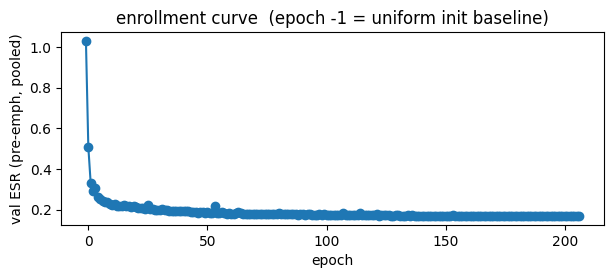

In [7]:
import pandas as pd
from IPython.display import Audio, display

from openamp.emulate.enroll import load_pair_model, render_dry

log = pd.read_csv(RUN_DIR / 'enroll' / 'pairs' / NAME / 'enroll_log.csv')
ax = log.plot(x='epoch', y='val_esr', marker='o', figsize=(7, 2.5), legend=False)
ax.set_ylabel('val ESR (pre-emph, pooled)')
ax.set_title(f'enrollment curve  (epoch -1 = {INIT} init baseline)')

enrolled, blob = load_pair_model(RUN_DIR, NAME, device=DEVICE)
R = enrolled.receptive_field
lo = n - int(round(metrics['val_seconds'] * cfg.sample_rate))
ctx = min(R, lo)                                  # real left-context from train side
pred = render_dry(enrolled, dry[lo - ctx:], device=DEVICE)[ctx:]

print(f"val region ({metrics['val_seconds']:.1f}s):  "
      f"raw ESR {metrics['val_esr_render_raw']:.4f}   "
      f"pre-emph {metrics['val_esr_render_preemph']:.4f}")
for label, sig in (('dry (input)', dry[lo:]),
                   ('wet (.nam target)', wet[lo:]),
                   ('prediction (enrolled one-to-many)', pred)):
    print(label)
    display(Audio(sig, rate=cfg.sample_rate, normalize=False))

In [8]:
import json

from openamp.emulate.export import export_profile

# Pasteable embedding profile for the morph plugin: {aaom_profile, name, run,
# dim, embedding}. `run` is the checkpoint's sha8, so the plugin can refuse a
# profile enrolled against a different network. Same schema/CLI as
# `openamp emulate-export-profile <run> --pair <name>`.
profile = export_profile(RUN_DIR, pair_name=NAME, name=NAME)
profile_path = RUN_DIR / 'enroll' / 'pairs' / NAME / 'profile.json'
profile_path.write_text(json.dumps(profile), encoding='utf-8')
print(f'wrote {profile_path}  ({profile_path.stat().st_size} bytes)')
print(f"  name={profile['name']!r}  run={profile['run']}  dim={profile['dim']}")

wrote results/emulate/nam_a2_tanh_ch16_512/enroll/pairs/nam_7. EVH Stealth G6 B7 M5 T7 P7 D5/profile.json  (10850 bytes)
  name='nam_7. EVH Stealth G6 B7 M5 T7 P7 D5'  run=1c646bbd  dim=512


**Notes**

- The `.nam` is the ground truth: enrollment can only be as faithful as the
  frozen net's capacity allows, so the val-render ESR is a clean read on how
  well one conditioning vector reproduces this amp.
- Alignment is free: the wet sweep is a render of dry, so lag is exactly 0
  (no correction needed, unlike `enroll_new_device.ipynb`'s recorded pairs).
- `INIT='uniform'`: the row starts at U(-a,a), the trainer's own init variance
  -- a new device starts where every trained device started. `'table_mean'`
  gives a lower epoch -1 baseline but starts at a point no trained device
  occupies. Compare runs on **best** val ESR, not the baseline.
- `STFT_WEIGHT=0` is required, not a default: with the run's trained weight
  the STFT term dominates a pair fit's gradient and val ESR rises instead of
  falling. At 0 the fit descends immediately. The corpus-render `enroll()`
  path is unaffected, so its own default stays 1.0.
- Native level, deliberately un-normalized -- see the dry cell.
- Expect a capacity ceiling well above trained-device ESR: one conditioning
  vector into a frozen, shared net cannot match a dedicated single-device
  model. Unfreezing the net (single-device fine-tune) is the only way past it.
- `DRY_SOURCE='sweep'` vs `'corpus'`: the frozen net has never seen sine
  sweeps, so a clean-corpus DI dry reaches meaningfully lower val ESR. Use
  `'corpus'` for the better fit, `'sweep'` for the exact TONE3000 protocol.
- CPU render of a multi-minute sweep takes a minute or two; set `DEVICE='cuda'`
  when the GPU is free.
- Batch enrolling: loop `NAM_PATH` over `cfg.captures_dir.rglob('*.nam')` and
  re-run the render + `enroll_pair` cells per file.
- The fitted vector lands in `<run>/enroll/pairs/<NAME>/enrolled_pair.pt`,
  concat-compatible with the run's `embedding.pt`.
- `profile.json` is the pasteable format the morph plugin loads directly
  (same schema as `openamp emulate-export-profile <run> --pair <name>`), and
  embeds `run` (the checkpoint's sha8) so the plugin refuses a mismatched
  profile. For the plugin's weight bundle, use
  `emulate-export-bundle --profile-pair <name>`.